In [7]:
import  numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.svm import SVC

In [3]:
x,y=make_regression(n_samples=1000,n_features=2,n_targets=1,noise=3.0)

In [4]:
x

array([[ 1.1306745 ,  2.08211827],
       [ 0.52528975,  0.62763443],
       [ 2.07769151, -0.95460333],
       ...,
       [-0.86666536,  0.06853616],
       [-0.50077398,  0.75608393],
       [ 0.05602256, -0.38207848]])

In [5]:
y

array([ 1.76668796e+02,  5.81848662e+01,  3.72462415e+01,  5.88755192e-02,
       -7.64732876e+01, -5.67646339e+01,  1.81105255e+01, -2.44715927e+01,
       -2.02193999e+01, -1.76580209e+02, -2.89864435e+01, -1.15009038e+02,
       -7.71488908e+01, -1.33081179e+01, -2.62374000e+01, -5.00265603e+00,
        1.46970292e+02,  7.10381527e+01, -8.46158895e+01, -2.84676174e+01,
       -2.89359792e+01, -9.67065605e+01,  2.16858729e+01,  3.49727563e+01,
        1.55211716e+01,  1.13276686e+02,  1.91857618e+02,  4.36425948e+00,
       -1.27546356e+01, -4.53996621e+01,  4.22047443e+01, -6.95950747e+01,
       -7.59160840e+01, -5.96088810e+01,  1.75558689e+01,  8.96251744e+01,
        2.12738670e+01, -6.97464376e+01, -4.37070728e+01,  1.62106594e+02,
        4.55813809e+01,  3.45927419e+01,  7.30185412e+01,  2.58004014e+00,
       -9.46919311e+01, -2.65708618e+00, -7.63607474e+01,  9.22899260e+01,
        6.69906929e+01, -6.45208113e+01,  9.83853364e+01,  1.53219318e+02,
       -1.24806332e+02,  

<Axes: xlabel='0', ylabel='1'>

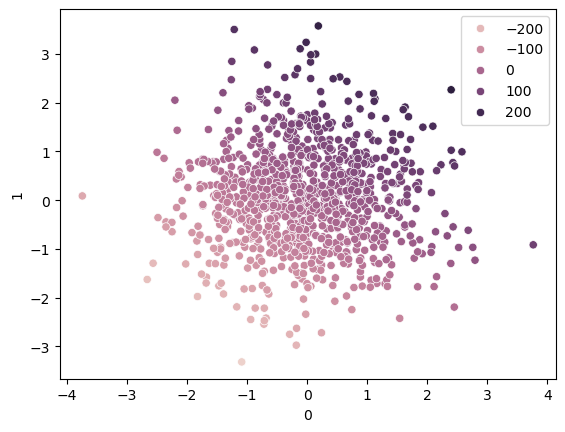

In [6]:
sns.scatterplot(x=pd.DataFrame(x)[0] ,y=pd.DataFrame(x)[1],hue=y)

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state =10)
from sklearn.svm import SVR

In [9]:
svr = SVR(kernel="linear")

In [11]:
svr.fit(x_train,y_train)

SVR(kernel='linear')

In [13]:
svr.coef_

array([[44.32290977, 61.43879751]])

In [14]:
y_pred=svr.predict(x_test)

In [15]:
y_pred

array([ 100.43158246,   48.14418636,  -27.3816568 ,   62.81246405,
        -24.40405551,  -82.40014075,  130.61585128,   17.88422613,
       -113.35228504,   84.57562081,   50.75605541,   79.28042743,
         75.71180313, -105.70526661,   33.96464864,  -26.19478972,
         12.4348426 ,   16.82862729,  -51.36825766,    6.91587473,
          9.55609308,   95.3423947 ,   93.01441223,   14.78165566,
        116.23726518,  147.29840431, -105.18218052,   52.31217172,
        -95.34132347,  -24.92593505,   -6.06523539,   74.70166243,
        -66.97627048,  -75.5764303 ,   -8.07899136,  -22.10366993,
          1.49961566,  120.01273966,  -70.30380487,   69.538948  ,
         83.40069675,  -38.21186599,  -38.08225386, -105.4007386 ,
        -12.1081289 ,   90.4192197 ,  -27.45098327, -129.81685833,
         75.66705123,  -46.35825975,    5.78510442,  -22.24722606,
        109.33852647,  -40.81503863,  -20.7899739 ,   -0.72342952,
       -152.08393086,   41.92085566,  180.01882822,   23.94368

In [16]:
from sklearn.metrics import r2_score

In [17]:
print(r2_score(y_test,y_pred))

0.9980618605547719


In [18]:
from sklearn.model_selection import GridSearchCV

In [19]:
#definig parMETER range
param_grid={"C":[0.1,1,10,100,1000],
            "gamma":[1,0.1,0.01,0.001,0.0001],
            "kernel":["linear"],
            'epsilon':[0.1,0.2,0.3]
}

In [22]:
grid = GridSearchCV(SVR(),param_grid = param_grid,refit=True,cv=5,verbose=3)

In [23]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
[CV 1/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.852 total time=   0.1s
[CV 2/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.856 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.867 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.856 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.857 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.852 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.856 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.867 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.856 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.857 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.1, gamma

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'epsilon': [0.1, 0.2, 0.3],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['linear']},
             verbose=3)

In [24]:
grid.best_params_

{'C': 1000, 'epsilon': 0.3, 'gamma': 1, 'kernel': 'linear'}

In [ ]:
y_pred=grid.pr